# Interpreting Clusters


In [1]:
path_data = '../../data/'

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline


```{contents}
:local:
:depth: 2
```


This section shows how to interpret a k-means result after the model has been fit. The technical output is only the starting point. The analyst still has to choose a reasonable number of clusters, describe each cluster, and decide whether the grouping supports the business question.

We work with an online store's customers. For each of 240 customers, the data record the amount spent in the last year (`annual_spend`, in dollars) and the number of orders placed (`orders_per_year`). Marketing wants to know whether customers fall into groups that call for different treatment.

```{note}
`customer_segments.csv` is a **synthetic** data set generated for this book with four built-in customer types, so we can see whether k-means finds them. Real customer data are messier, and the groups are rarely this clean.
```


In [2]:
customers = pd.read_csv(path_data + 'customer_segments.csv')
customers.head()


,customer_id,annual_spend,orders_per_year
0,C001,1133,25
1,C002,443,2
2,C003,1327,18
3,C004,731,28
4,C005,898,26


**Scale the features first.** The two features are on very different scales: spend runs from about \$60 to \$3,400, while orders run from 1 to 35. K-means groups points by distance, so without scaling, a \$100 difference in spend counts as much as a difference of 100 orders, and the clusters form almost entirely by spend. Here is k-means with 4 clusters on the raw features and on the features in standard units, both plotted in the original units:


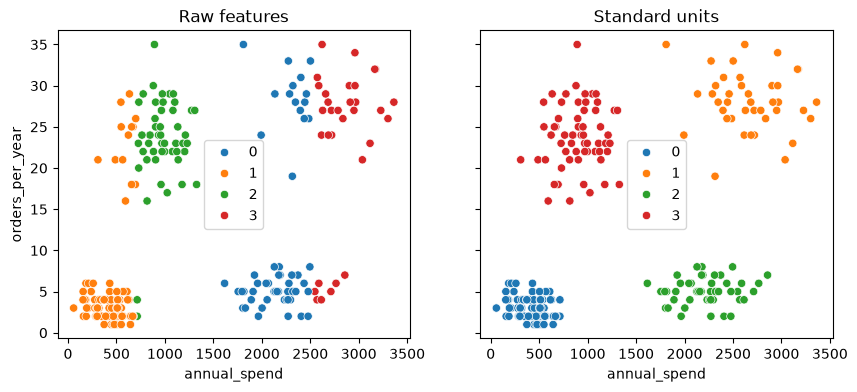

In [3]:
features = ['annual_spend', 'orders_per_year']
X = customers[features]
X_scaled = (X - X.mean()) / X.std(ddof=0)      # standard units

raw_labels = KMeans(n_clusters=4, n_init=10, random_state=101).fit_predict(X)
scaled_labels = KMeans(n_clusters=4, n_init=10, random_state=101).fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
sns.scatterplot(data=customers, x='annual_spend', y='orders_per_year', hue=raw_labels, palette='tab10', ax=axes[0])
axes[0].set_title('Raw features')
sns.scatterplot(data=customers, x='annual_spend', y='orders_per_year', hue=scaled_labels, palette='tab10', ax=axes[1])
axes[1].set_title('Standard units')
plt.show()


On the raw features (left), the clusters are bands of spend: customers who spend about the same land in the same cluster whether they order 3 times a year or 30. In standard units (right), both features count, and the clusters follow the customer types you can see in the plot. From here on, we cluster the scaled features.


## Choosing k

K-means needs the number of clusters up front. Two common heuristics are the elbow method and the silhouette score. These tools help compare choices, but they do not remove judgment. A technically neat value of `k` still needs a practical interpretation.

## Elbow Check

The **elbow method** fits k-means for several values of `k` and records the model's inertia, which is the within-cluster sum of squares. Lower inertia is better, but it always improves as `k` increases. The useful question is where the improvement starts to flatten.

In [4]:
inertias = []
k_values = range(2, 8)

for k in k_values:
    model = KMeans(n_clusters=k, n_init=10, random_state=101)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

elbow_df = pd.DataFrame({"k": list(k_values), "inertia": inertias})
elbow_df

,k,inertia
0,2,236.793172
1,3,116.569217
2,4,28.609085
3,5,24.227739
4,6,20.382649
5,7,17.746656


Text(0, 0.5, 'Inertia')

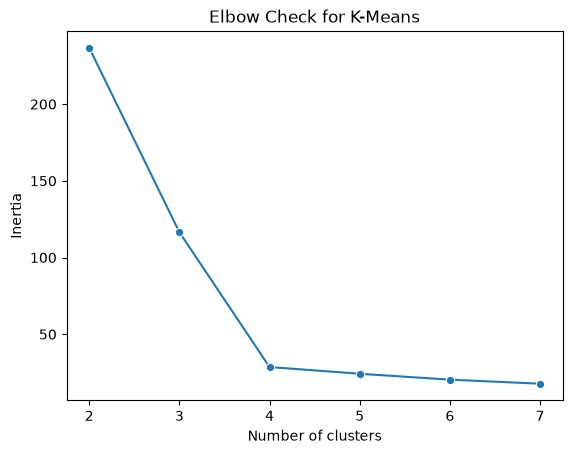

In [5]:
sns.lineplot(data=elbow_df, x="k", y="inertia", marker="o")
plt.title("Elbow Check for K-Means")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")

## Silhouette Check

The **silhouette score** compares how close each point is to its own cluster relative to nearby clusters. Values closer to 1 suggest tighter, better-separated clusters. Values near 0 suggest overlap, and negative values suggest points may be assigned to the wrong cluster.

In [6]:
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, n_init=10, random_state=101)
    labels = model.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

silhouette_df = pd.DataFrame({"k": list(k_values), "silhouette": silhouette_scores})
silhouette_df

,k,silhouette
0,2,0.516182
1,3,0.644066
2,4,0.771513
3,5,0.675900
4,6,0.629143
5,7,0.548643


Text(0, 0.5, 'Silhouette score')

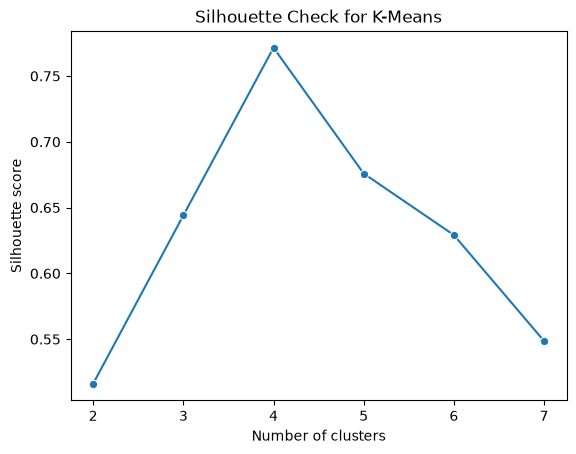

In [7]:
sns.lineplot(data=silhouette_df, x="k", y="silhouette", marker="o")
plt.title("Silhouette Check for K-Means")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")

Both checks point to **k = 4**. Inertia drops steeply up to 4 clusters and then barely improves, and the silhouette score is highest at 4 (about 0.77). In real data, the two checks often disagree or show no clear winner, and the business question has to break the tie.


## Describing Clusters

After choosing `k`, summarize each cluster in the units that matter for the decision. We fit the model on the scaled features, but we describe the clusters in the original units, dollars and orders, because those are what a manager can act on. In a customer example, that might mean average order value, purchase frequency, tenure, and churn rate. In an operations example, it might mean processing time, defect rate, and order size.

In [8]:
final_model = KMeans(n_clusters=4, n_init=10, random_state=101)
customers['cluster'] = final_model.fit_predict(X_scaled)

profile = customers.groupby('cluster')[features].mean().round(0)
profile['customers'] = customers['cluster'].value_counts().sort_index()
profile


,annual_spend,orders_per_year,customers
cluster,,,
0,410.0,3.0,90
1,2669.0,28.0,40
2,2221.0,5.0,50
3,902.0,24.0,60


## Practical Interpretation

Cluster labels are useful only when they support an interpretable decision. The final step is to describe the groups in business language and decide whether the segments suggest different actions.

The colors in a cluster plot are arbitrary. Cluster `0` in one model is not guaranteed to match cluster `0` in another model, even when the same data are used.

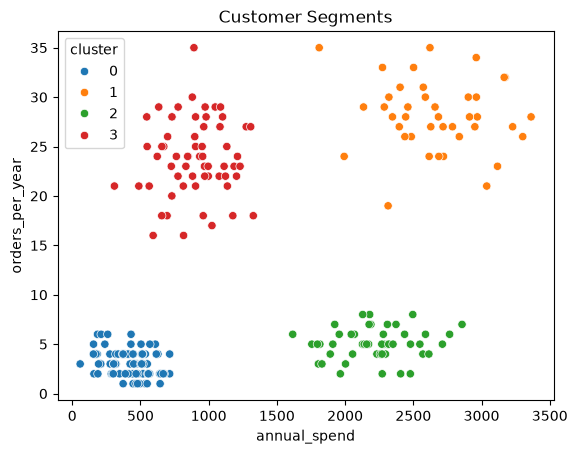

In [9]:
sns.scatterplot(data=customers, x='annual_spend', y='orders_per_year', hue='cluster', palette='tab10')
plt.title('Customer Segments')
plt.show()


Reading the profile table, we can name each cluster and propose an action for it:

| Cluster | Profile | Customers | Possible action |
|---:|---|---:|---|
| 0 | **Occasional buyers**: about \$410 a year over 3 orders | 90 | Low-cost reactivation emails; test a discount on a second purchase |
| 1 | **Loyal high-value**: about \$2,670 a year over 28 orders | 40 | Retention first: loyalty perks and early access; watch for any drop in orders |
| 2 | **Big-ticket buyers**: about \$2,220 a year over 5 orders | 50 | Follow each large purchase with accessories, service plans, and replacement reminders |
| 3 | **Frequent small baskets**: about \$900 a year over 24 orders | 60 | Raise the basket size with bundles and a free-shipping threshold |

These actions are hypotheses, not results. Before rolling one out, test it, for example with an A/B test that compares customers who get the offer with similar customers who don't (Chapter 10). Also check that the segments are stable: if a new month of data or a different random start reshuffles the customers, the segments are not a solid basis for a decision.


## Practical Tips

- Scale features before clustering when units differ.
- Run multiple initializations with `n_init` to avoid poor local minima.
- Use `random_state` for reproducible examples.
- Treat cluster labels as arbitrary identifiers, not ranked categories.
- Validate clusters with domain knowledge before using them for decisions.


## Section Practice

Use this short exercise to check the main workflow from this section.


In [10]:
### Exercise: Practice Interpreting Clusters
# A model produced the predictions and actual values below.
# Calculate each error as actual minus predicted. Then print the mean absolute error.
predicted = [98, 105, 110, 120]
actual = [100, 102, 114, 119]
### Your code starts here




### Your code ends here


In [11]:
### Solution
predicted = [98, 105, 110, 120]
actual = [100, 102, 114, 119]
errors = [a - p for a, p in zip(actual, predicted)]
mean_absolute_error = sum(abs(error) for error in errors) / len(errors)
print(errors)
print(mean_absolute_error)


[2, -3, 4, -1]
2.5


In [12]:
### Exercise: Section Practice 1
# book-rule-sparse-practice
# A manager wants a short check on the chapter section named below.
# Create a list named steps with three actions: identify decision, choose metric, explain result.
# Print exactly these three lines, using the existing section_focus value:
# Section: Choosing k
# Steps: 3
# First step: identify decision
section_focus = 'Choosing k'

### Your code starts here.

### Your code ends here.


In [13]:
section_focus = 'Choosing k'
steps = ["identify decision", "choose metric", "explain result"]
print("Section:", section_focus)
print("Steps:", len(steps))
print("First step:", steps[0])


Section: Choosing k
Steps: 3
First step: identify decision


In [14]:
### Exercise: Section Practice 2
# book-rule-sparse-practice
# The chapter uses the section headings to organize related ideas.
# Store the three provided terms in a list named representative_terms.
# Print exactly these two lines:
# Terms: Choosing, Elbow, Check
# Term count: 3
provided_terms = ['Choosing', 'Elbow', 'Check']

### Your code starts here.

### Your code ends here.


In [15]:
representative_terms = ['Choosing', 'Elbow', 'Check']
print("Terms:", ", ".join(representative_terms))
print("Term count:", len(representative_terms))


Terms: Choosing, Elbow, Check
Term count: 3
